In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("dataset.csv")

In [2]:
print(df.shape)

(114000, 21)


Tiene 114 mil renglones y 21 columnas.

In [3]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

+ `track_id`: Identificador único de la canción dentro de Spotify.

+ `artists`: Nombre o nombres de los artistas que interpretan la canción. Si hay varios artistas, aparecen separados por punto y coma (;).

+ `album_name`: Nombre del álbum al que pertenece la canción.

+ `track_name`: Nombre de la canción.

+ `popularity`: Nivel de popularidad de la canción en una escala de 0 a 100. Un valor de 100 corresponde a las canciones más populares de Spotify.

+ `duration_ms`: Duración de la canción medida en milisegundos.

+ `explicit`: Indica si la canción contiene lenguaje o contenido explícito. Toma valores True (sí) o False (no).

+ `danceability`: Mide qué tan adecuada es la canción para bailar considerando factores como ritmo, estabilidad del compás y fuerza del beat. Toma valores entre 0 y 1.

+ `energy`: Mide la intensidad y actividad percibida de la canción. Valores cercanos a 1 representan canciones más energéticas, rápidas y fuertes.

+ `key`: Tonalidad musical de la canción representada mediante números del 0 al 11. Cada número corresponde a una nota musical específica.

+ `loudness`: Volumen general de la canción medido en decibeles (dB).
mode: Modo musical de la canción. Un valor de 1 indica modo mayor y 0 indica modo menor.

+ `speechiness`: Mide la presencia de palabras habladas en la grabación. Valores altos indican contenido predominantemente hablado.

+ `acousticness`: Indica la probabilidad de que la canción sea acústica. Valores cercanos a 1 representan una mayor confianza de que la canción es acústica.

+ `instrumentalness`: Estima la probabilidad de que la canción no contenga voz. Valores altos indican canciones principalmente instrumentales.

+ `liveness`: Mide la probabilidad de que la grabación haya sido realizada en vivo frente a una audiencia.

+ `valence`: Mide la positividad emocional transmitida por la canción. Valores altos suelen asociarse con música alegre o positiva, mientras que valores bajos se relacionan con música más triste o melancólica.

+ `tempo`: Velocidad o ritmo de la canción medida en pulsaciones por minuto (BPM).

+ `time_signature`: Compás musical estimado de la canción. Indica cuántos tiempos contiene cada compás musical.

+ `track_genre`: Género musical al que pertenece la canción.

In [4]:
df = df.drop(columns=['Unnamed: 0'])

In [5]:
df.head(3)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [6]:
print(df.describe())

          popularity   duration_ms   danceability         energy  \
count  114000.000000  1.140000e+05  114000.000000  114000.000000   
mean       33.238535  2.280292e+05       0.566800       0.641383   
std        22.305078  1.072977e+05       0.173542       0.251529   
min         0.000000  0.000000e+00       0.000000       0.000000   
25%        17.000000  1.740660e+05       0.456000       0.472000   
50%        35.000000  2.129060e+05       0.580000       0.685000   
75%        50.000000  2.615060e+05       0.695000       0.854000   
max       100.000000  5.237295e+06       0.985000       1.000000   

                 key       loudness           mode    speechiness  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        5.309140      -8.258960       0.637553       0.084652   
std         3.559987       5.029337       0.480709       0.105732   
min         0.000000     -49.531000       0.000000       0.000000   
25%         2.000000     -10.013000       

# Valores Faltates

In [7]:
print(df. isnull().sum())

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


En 3 columnas hay un falante.

In [8]:
df['artists'] = df['artists'].fillna('Unknown')
df['album_name'] = df['album_name'].fillna('Unknown')
df['track_name'] = df['track_name'].fillna('Unknown')

#  Valores Duplicados y Unicos

In [10]:
print(df['track_id'].duplicated().sum())
print(df['track_id'].nunique())

24259
89741


Unicamente hay 89,741 valores unido en `track_id`

+ indica la existencia de canciones repetidas, posiblemente asociadas a distintos géneros, álbumes o versiones




In [11]:
print(df['track_name'].duplicated().sum())
print(df['track_name'].nunique())

40391
73609


Hay 73,608 valores unicos en `track_name`

+ hay menos nombres unicos que IDs
+ existen canciones diferentes con el mismo nombre
+ existen remixes, versiones en vivo o grabaciones distintas con títulos idénticos.

In [12]:
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [13]:
duplicados = df[df['track_id'].duplicated(keep=False)] #mostrar todas las filas cuyo track_id aparece mas de una vez en el df
duplicados.sort_values('track_id').head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,chill
103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,soul
85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,ska
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,rock
3257,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alternative
2106,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,emo
94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,sad
97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),Agora Estou Sofrendo - Ao Vivo,47,260510,False,0.605,0.678,0,-3.257,1,0.0311,0.64200,0.000000,0.1570,0.439,125.059,4,sertanejo


+ no hay filas completamente duplicadas, en estos registros todas las características de audio permanecen iguales y únicamente cambia la variable `track_genre`

In [14]:
genres_por_track = df.groupby('track_id')['track_genre'].nunique()
genres_por_track.describe()

,track_genre
count,89741.000000
mean,1.265308
std,0.664204
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,9.000000


In [15]:
100 * (genres_por_track > 1).mean()

np.float64(18.16226696827537)

+ el 14% de las canciones está asociada a más de un género musical

# Correlacion

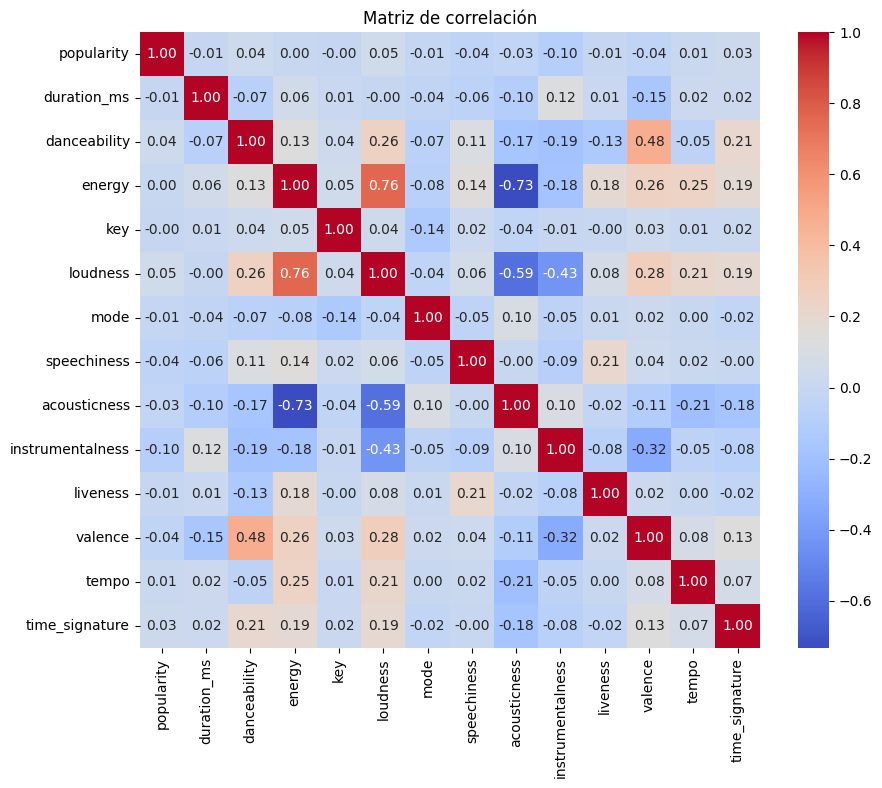

In [16]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación')
plt.show()

+ no existe una relación lineal fuerte entre la popularidad y una característica acustica individual

+ la popularidad depende de múltiples factores y no únicamente de los atributos musicales medidos por Spotify

Sin embargo, existe otras correlaciones:

+ correlación positiva entre energía y loudness, indicando que las canciones con mayor intensidad musical tienden a presentar niveles más altos de loudness. Las canciones más energéticas suelen ser más ruidosas

+ existe una relación moderada entre danceability y valence, sugiriendo que las canciones más adecuadas para bailar suelen presentar una mayor positividad emocional

+ Loudness y Acousticness, las canciones acústicas suelen ser menos ruidosas

+ las variables energy y acousticness presentan una fuerte relación inversa, lo que indica que las canciones predominantemente acústicas suelen caracterizarse por menores niveles de energía


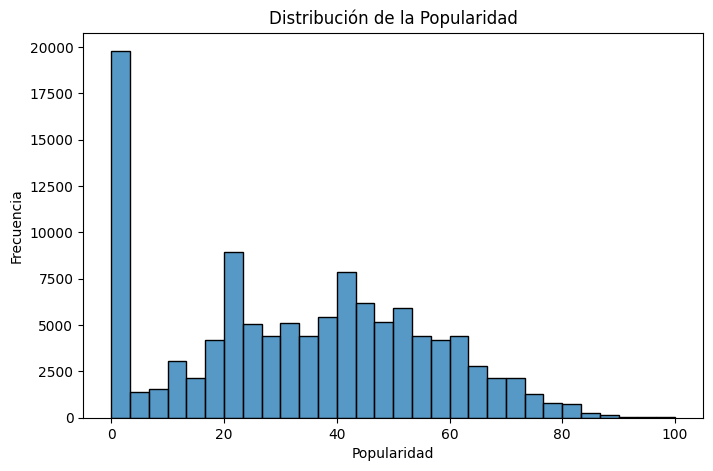

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='popularity',
    bins=30,
)

plt.title('Distribución de la Popularidad')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')

plt.show()

+ una gran cantidad de canciones tienen poca o ninguna popularidad

+  concentración de canciones con niveles de popularidad muy bajos

+ distribución multimodal y asimetrica

In [18]:
print((df['popularity'] == 0).sum())
print(100 * (df['popularity'] == 0).mean())

16020
14.05263157894737


Aproximadamente el 14.05% de las canciones del conjunto de datos presentan una popularidad igual a cero, esto indica que una fracción importante del catálogo no registra un nivel significativo de interacción o reproducción dentro de la plataforma.

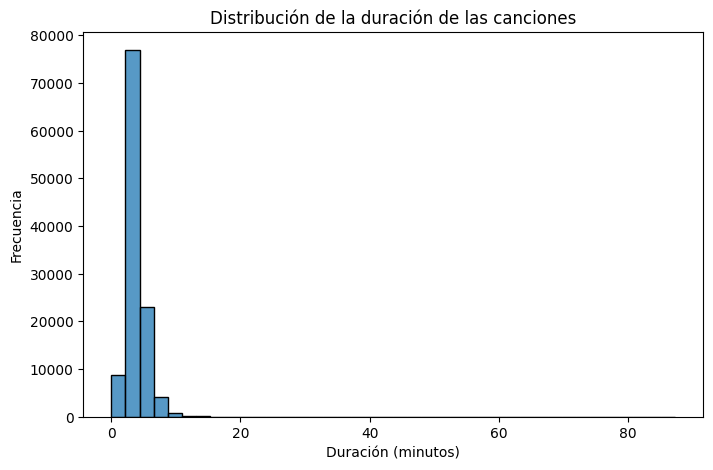

In [19]:
df['duration_min'] = df['duration_ms'] / 60000

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='duration_min',
    bins=40
)

plt.title('Distribución de la duración de las canciones')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

plt.show()

+ cola hacia la derecha
+ hay canciones que duran mas de 80 min, muy inisual


In [20]:
df.sort_values(
    by='duration_min',
    ascending=False
)[['track_name',
   'artists',
   'track_genre',
   'speechiness',
   'duration_min']].head(10)

,track_name,artists,track_genre,speechiness,duration_min
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,minimal-techno,0.0374,87.288250
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,breakbeat,0.0451,79.817100
10984,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,breakbeat,0.0451,79.817100
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,detroit-techno,0.0633,78.838367
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,minimal-techno,0.0612,76.064950
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,chicago-house,0.0711,74.125333
13245,Live In Tokyo - Continuous Mix,Mark Farina,chicago-house,0.0874,72.330433
13195,Greenhouse Construction,Mark Farina,chicago-house,0.0611,72.245350
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,drum-and-bass,0.0899,70.770100
101390,Ocean Waves Sounds,Ocean Sounds,sleep,0.0612,68.670967


+ los registros con mayor duración no corresponden a podcasts, audiolibros ni contenido hablado, ya que sus valores de speechiness son muy bajos

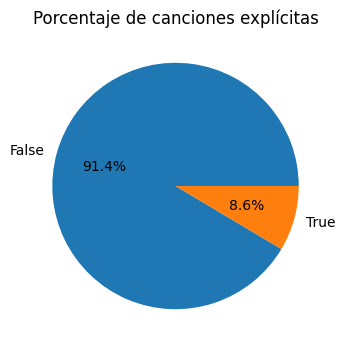

In [21]:
conteo = df['explicit'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    conteo,
    labels=conteo.index,
    autopct='%1.1f%%'
)

plt.title('Porcentaje de canciones explícitas')

plt.show()

Solo el 8.6% de las canciones contiene palabras explicitas

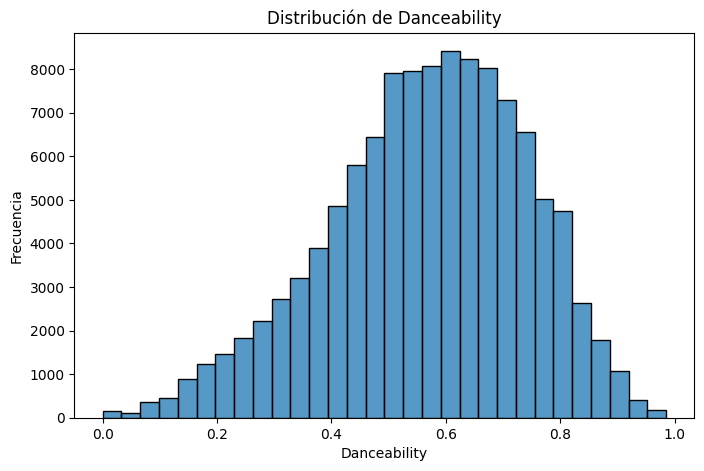

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='danceability',
    bins=30,
)

plt.title('Distribución de Danceability')
plt.xlabel('Danceability')
plt.ylabel('Frecuencia')

plt.show()

+ La variable danceability presenta una distribución unimodal con una concentración importante entre 0.5 y 0.8, esto indica que la mayoría de las canciones del conjunto de datos poseen características  para el baile

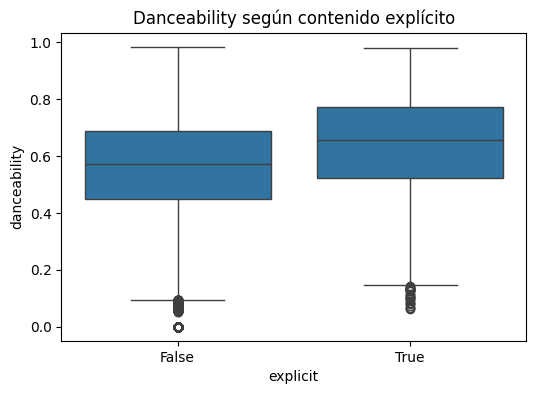

In [23]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='explicit',
    y='danceability'
)

plt.title('Danceability según contenido explícito')

plt.show()

+ Las canciones con contenido explícito tienden a presentar niveles de danceability superiores a las canciones no explícitas

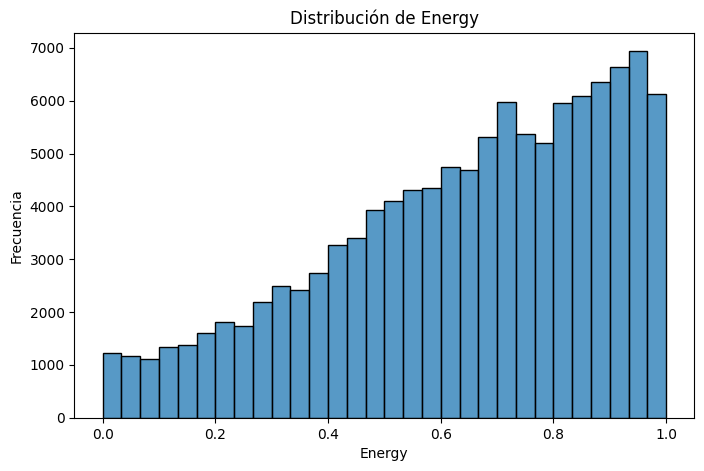

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='energy',
    bins=30,
)

plt.title('Distribución de Energy')
plt.xlabel('Energy')
plt.ylabel('Frecuencia')

plt.show()

la gran mayoría de las canciones tienen niveles de energía de moderados a altos

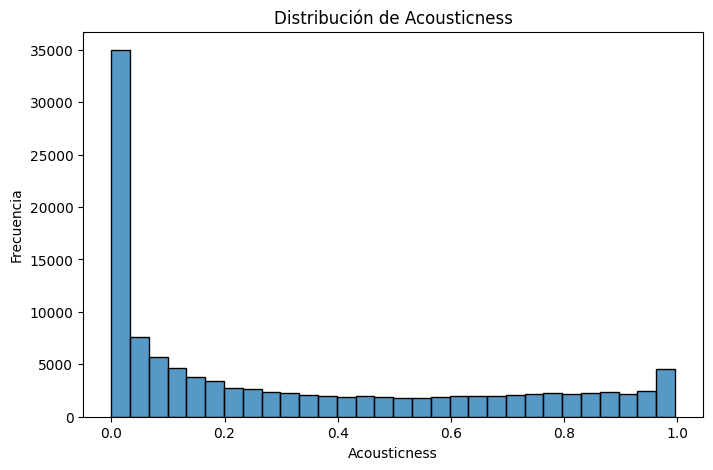

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='acousticness',
    bins=30
)

plt.title('Distribución de Acousticness')
plt.xlabel('Acousticness')
plt.ylabel('Frecuencia')

plt.show()

la mayoría de las canciones no son acústicas

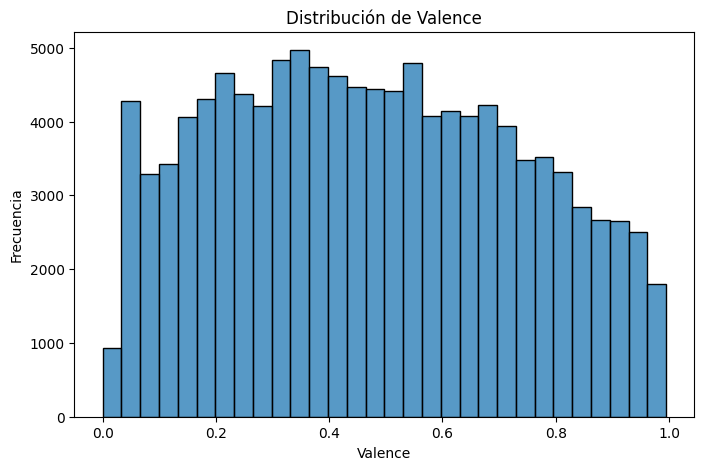

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='valence',
    bins=30
)

plt.title('Distribución de Valence')
plt.xlabel('Valence')
plt.ylabel('Frecuencia')

plt.show()

Los valores estan bien distribuidos, muy pocas canciones demasiado tristes

In [27]:
df[['energy',
    'acousticness',
    'valence',
    'speechiness']].describe()

,energy,acousticness,valence,speechiness
count,114000.000000,114000.000000,114000.000000,114000.000000
mean,0.641383,0.314910,0.474068,0.084652
std,0.251529,0.332523,0.259261,0.105732
min,0.000000,0.000000,0.000000,0.000000
25%,0.472000,0.016900,0.260000,0.035900
50%,0.685000,0.169000,0.464000,0.048900
75%,0.854000,0.598000,0.683000,0.084500
max,1.000000,0.996000,0.995000,0.965000


<Axes: xlabel='explicit', ylabel='popularity'>

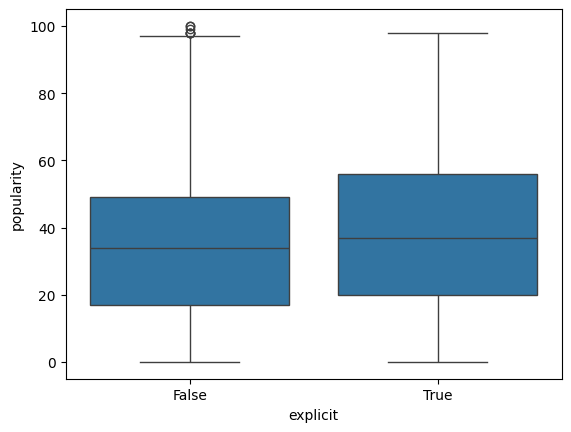

In [28]:
sns.boxplot(
    data=df,
    x='explicit',
    y='popularity'
)

las canciones explícitas tienen una ligera ventaja competitiva en el algoritmo de Spotify para alcanzar mayor popularidad, pero no es mucha la diferencia

# Generos mas populares

<Axes: ylabel='track_genre'>

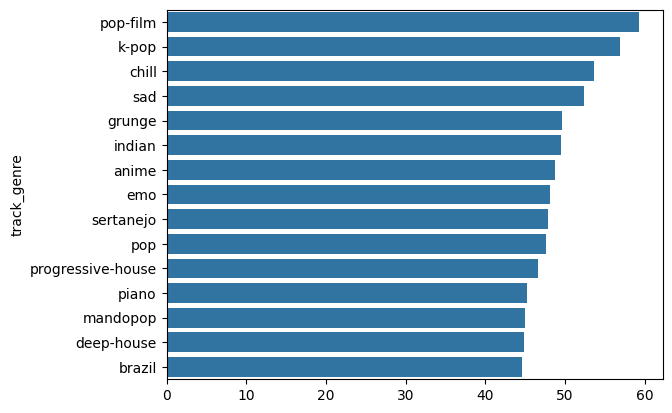

In [29]:
pop_gen = (
    df.groupby('track_genre')['popularity']
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

sns.barplot(
    x=pop_gen.values,
    y=pop_gen.index
)

los generos mas populares el pop-film y k-pop

# Top 10 mas populares

In [30]:
top10 = df.sort_values(
    'popularity',
    ascending=False
).head(10)

top10[['track_name',
       'artists',
       'track_genre',
       'popularity']]

,track_name,artists,track_genre,popularity
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
89411,La Bachata,Manuel Turizo,reggaeton,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,edm,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,pop,98
88410,La Bachata,Manuel Turizo,reggae,98
67356,La Bachata,Manuel Turizo,latin,98
68303,La Bachata,Manuel Turizo,latino,98


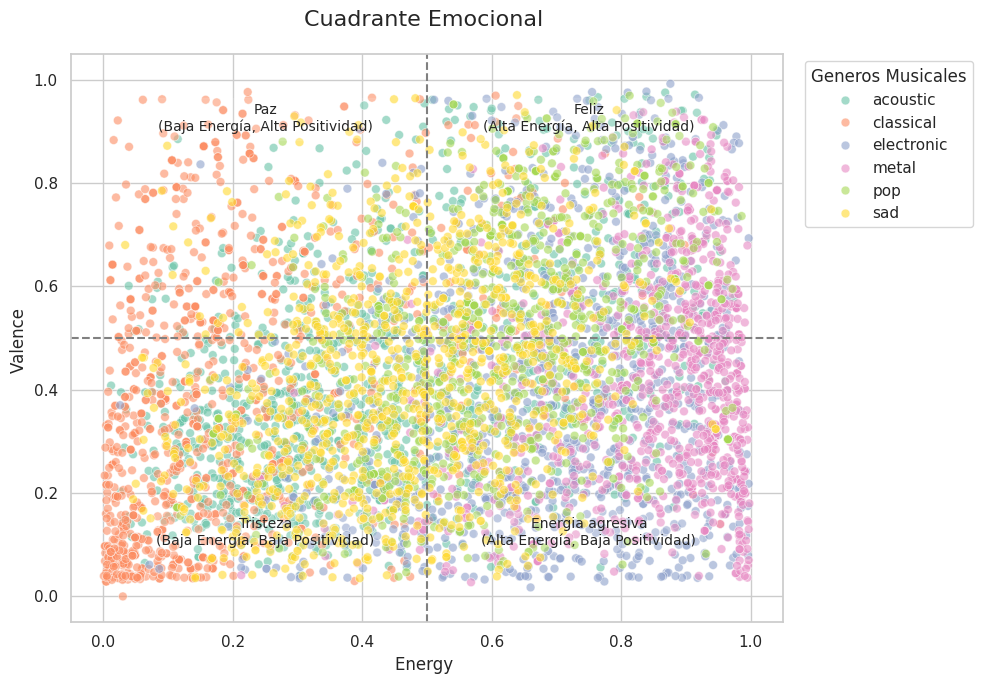

In [48]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.set_theme(style="whitegrid")

generos_interes = ['pop', 'metal', 'classical', 'electronic', 'acoustic', 'sad']
df_filtrado = df[df['track_genre'].isin(generos_interes)]

sns.scatterplot(
    data=df_filtrado,
    x='energy',
    y='valence',
    hue='track_genre',
    palette='Set2',
    alpha=0.6,
    s=40
)

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5)
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)

plt.text(0.75, 0.90, "Feliz\n(Alta Energía, Alta Positividad)",
         fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.1))

plt.text(0.75, 0.10, "Energia agresiva\n(Alta Energía, Baja Positividad)",
         fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.1))

plt.text(0.25, 0.90, "Paz\n(Baja Energía, Alta Positividad)",
         fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.1))

plt.text(0.25, 0.10, "Tristeza\n(Baja Energía, Baja Positividad)",
         fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.1))

plt.title('Cuadrante Emocional ', fontsize=16, pad=20)
plt.xlabel('Energy ', fontsize=12)
plt.ylabel('Valence ', fontsize=12)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.legend(title='Generos Musicales', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()